Pertemuan 6 - Preprocessing Dataset Titanic

Nama: Alini Syawalia Riski Fenanda
NIM: 240401010213
Mata Kuliah: Data Science

Pendahuluan

Preprocessing data merupakan tahap penting dalam Data Science dan Machine Learning karena kualitas data sangat memengaruhi performa model yang akan dibangun. Dataset yang belum diproses biasanya memiliki berbagai permasalahan seperti missing values, data kategorikal yang belum dapat dipahami oleh algoritma, serta perbedaan skala antar fitur.

Pada praktikum ini dilakukan proses preprocessing menggunakan dataset Titanic yang berisi informasi penumpang kapal Titanic dan status keselamatan mereka. Dataset ini dipilih karena memiliki kombinasi fitur numerik dan kategorikal, terdapat missing values, serta target yang tidak seimbang sehingga cocok digunakan untuk mempelajari tahapan persiapan data secara menyeluruh.

Tujuan praktikum ini adalah:

1. Memahami struktur dataset Titanic.
2. Melakukan eksplorasi data sederhana (EDA).
3. Menangani missing values.
4. Mengubah data kategorikal menjadi numerik menggunakan One-Hot Encoding.
5. Membagi data menjadi training set dan testing set.
6. Melakukan feature scaling menggunakan StandardScaler.
7. Menghasilkan dataset yang siap digunakan untuk proses Machine Learning.

Langkah 1 - Load Dataset dan Exploratory Data Analysis (EDA)
Tujuan

Pada tahap ini dilakukan:

Memuat dataset Titanic.
Memeriksa jumlah data dan fitur.
Mengidentifikasi missing values.
Melihat distribusi target (survived).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset Titanic
df = sns.load_dataset('titanic')

# Pilih kolom yang digunakan
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch',
        'fare', 'embarked', 'survived']

df = df[cols].copy()

print("Shape Dataset:", df.shape)

print("\nTipe Data:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDistribusi Target:")
print(df['survived'].value_counts(normalize=True).round(3))

Shape Dataset: (891, 8)

Tipe Data:
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
survived      int64
dtype: object

Missing Values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Distribusi Target:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


Visualisasi Distribusi Target

Visualisasi dilakukan untuk mengetahui apakah data target seimbang atau tidak.

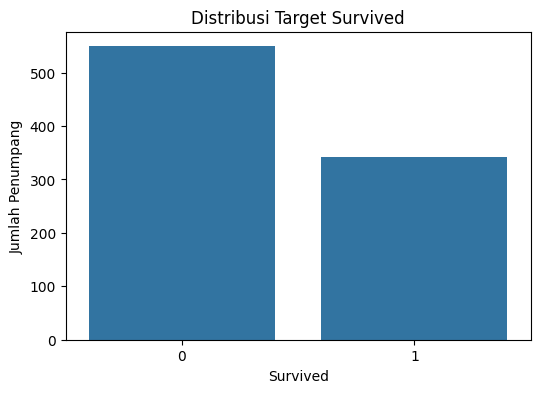

In [2]:
plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df)

plt.title('Distribusi Target Survived')
plt.xlabel('Survived')
plt.ylabel('Jumlah Penumpang')
plt.show()

Interpretasi

Berdasarkan visualisasi terlihat bahwa:

Kelas 0 (Tidak Selamat) lebih banyak dibandingkan kelas 1 (Selamat).
Dataset memiliki ketidakseimbangan kelas (class imbalance).
Oleh karena itu pada tahap train-test split akan digunakan stratifikasi agar proporsi kelas tetap terjaga.

Langkah 2 - Handling Missing Values
Tujuan

Data yang memiliki nilai kosong perlu ditangani sebelum digunakan oleh algoritma Machine Learning.

Strategi yang digunakan:

Kolom numerik (age) → Median
Kolom kategorikal (embarked) → Modus

Median dipilih karena lebih tahan terhadap outlier dibandingkan mean.

In [3]:
# Cek missing values sebelum handling
print("Missing Values Sebelum:")
print(df.isnull().sum())

# Age menggunakan median
df['age'] = df['age'].fillna(df['age'].median())

# Embarked menggunakan modus
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print("\nMissing Values Setelah:")
print(df.isnull().sum())

Missing Values Sebelum:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Missing Values Setelah:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


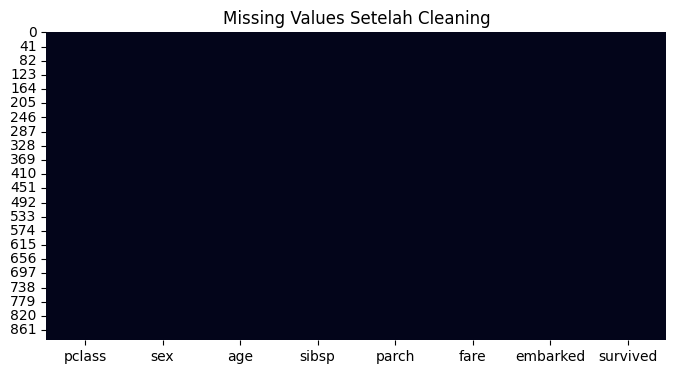

In [4]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Setelah Cleaning")
plt.show()

Interpretasi

Setelah proses imputasi, seluruh missing values berhasil diatasi sehingga dataset siap untuk tahap berikutnya.

Langkah 3 - Encoding Data Kategorikal
Tujuan

Algoritma Machine Learning tidak dapat langsung memproses data bertipe string.

Kolom yang perlu diubah:

1. sex
2. embarked

Metode yang digunakan adalah One-Hot Encoding.

In [5]:
df = pd.get_dummies(
    df,
    columns=['sex', 'embarked'],
    drop_first=True,
    dtype=int
)

print("Kolom Setelah Encoding:")
print(df.columns.tolist())

Kolom Setelah Encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']


Hasil

Kolom baru yang terbentuk:

1. sex_male
2. embarked_Q
3. embarked_S

Langkah 4 - Train-Test Split
Tujuan

Dataset dibagi menjadi:

1. Training Set (80%)
2. Testing Set (20%)

Digunakan parameter stratify agar distribusi kelas target tetap proporsional.

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (712, 8)
X_test : (179, 8)
y_train: (712,)
y_test : (179,)


In [7]:
print("Proporsi Train:")
print(y_train.value_counts(normalize=True).round(3))

print("\nProporsi Test:")
print(y_test.value_counts(normalize=True).round(3))

Proporsi Train:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi Test:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


Interpretasi

Distribusi kelas pada training dan testing set tetap hampir sama sehingga model tidak mengalami bias akibat pembagian data.

Langkah 5 - Feature Scaling
Tujuan

Fitur numerik memiliki rentang nilai yang berbeda-beda.

Contoh:

1. Age → 0 sampai 80 tahun
2. Fare → hingga ratusan

Perbedaan skala ini dapat memengaruhi performa beberapa algoritma Machine Learning.

Metode yang digunakan adalah StandardScaler.

In [8]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

scaler = StandardScaler()

# Fit pada train
X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

# Transform pada test
X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

print("Mean:")
print(scaler.mean_.round(2))

print("\nStandard Deviation:")
print(scaler.scale_.round(2))

Mean:
[ 2.31 29.46  0.49  0.39 31.82]

Standard Deviation:
[ 0.83 13.03  1.06  0.84 48.03]


In [9]:
print("Contoh Data Training:")
display(X_train.head())

Contoh Data Training:


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
692,0.829568,-0.112078,-0.465084,-0.466183,0.513812,1,0,1
481,-0.370945,-0.112078,-0.465084,-0.466183,-0.662563,1,0,1
527,-1.571457,-0.112078,-0.465084,-0.466183,3.955399,1,0,1
855,0.829568,-0.879807,-0.465084,0.727782,-0.467874,0,0,1
801,-0.370945,0.118241,0.478335,0.727782,-0.115977,0,0,1


Interpretasi

Setelah scaling:

1. Nilai rata-rata mendekati 0.
2. Standar deviasi mendekati 1.
3. Fitur numerik memiliki skala yang seragam.

Langkah 6 - Dataset Siap Digunakan
Verifikasi Akhir

In [10]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nTidak ada missing values:")
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

X_train: (712, 8)
y_train: (712,)
X_test : (179, 8)
y_test : (179,)

Tidak ada missing values:
0
0


In [11]:
print(df.describe())

           pclass         age       sibsp       parch        fare    survived  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     2.308642   29.361582    0.523008    0.381594   32.204208    0.383838   
std      0.836071   13.019697    1.102743    0.806057   49.693429    0.486592   
min      1.000000    0.420000    0.000000    0.000000    0.000000    0.000000   
25%      2.000000   22.000000    0.000000    0.000000    7.910400    0.000000   
50%      3.000000   28.000000    0.000000    0.000000   14.454200    0.000000   
75%      3.000000   35.000000    1.000000    0.000000   31.000000    1.000000   
max      3.000000   80.000000    8.000000    6.000000  512.329200    1.000000   

         sex_male  embarked_Q  embarked_S  
count  891.000000  891.000000  891.000000  
mean     0.647587    0.086420    0.725028  
std      0.477990    0.281141    0.446751  
min      0.000000    0.000000    0.000000  
25%      0.000000    0.000000    0.000000  
50%   

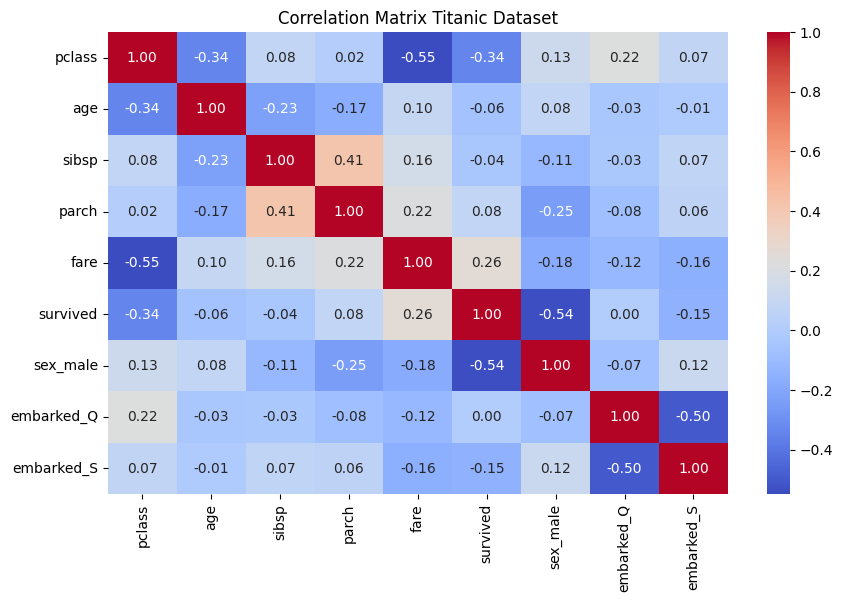

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix Titanic Dataset")
plt.show()

Interpretasi Korelasi
1. Fare memiliki hubungan positif dengan peluang selamat.
2. Pclass memiliki hubungan negatif dengan peluang selamat.
3. Jenis kelamin juga menjadi faktor yang cukup berpengaruh terhadap tingkat keselamatan penumpang.

Kesimpulan

Pada praktikum ini telah dilakukan preprocessing dataset Titanic secara end-to-end yang meliputi:

1. Memuat dan memahami dataset melalui EDA sederhana.
2. Menangani missing values menggunakan median dan modus.
3. Melakukan One-Hot Encoding pada fitur kategorikal.
4. Membagi data menjadi training dan testing set menggunakan stratifikasi.
5. Melakukan feature scaling menggunakan StandardScaler.
6. Menghasilkan dataset yang bersih dan siap digunakan untuk proses Machine Learning.

Dengan preprocessing yang baik, kualitas data menjadi lebih optimal sehingga dapat meningkatkan performa model Machine Learning pada tahap pelatihan dan evaluasi berikutnya.